In [1]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
from scipy.spatial.distance import cdist, squareform, pdist
from scipy.stats import zscore, pearsonr
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
#import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import sparse
import scipy.sparse as sp
from anndata import AnnData
import gc
import time
import csv

In [24]:
#import nbimporter
import cfunct as cf
#from cfunct import *

In [16]:
def bootstrap_euclidean_interset(adata, reference_adata, n_iter):
    """
    Function calculates the Euclidean distance between the means of clusters
    in 'adata' and 'reference_adata' by bootstrap sampling, over 'n_iter' iterations.

    Args:
        adata: Anndata object containing the first dataset with cluster assignments.
        reference_adata: Anndata object containing the reference dataset with its 
                         own cluster assignments.
        n_iter (int): Number of bootstrap iterations to perform.

    Returns:
        numpy.ndarray: A 3D array of shape (n_iter, n_clusts_ref, n_clusts) containing 
                       the Euclidean distances calculated in each iteration.
        list: Names of the clusters in 'adata'.
        list: Names of the clusters in 'reference_adata'.
    """
    n_vars = adata.n_vars
    n_vars_ref = reference_adata.n_vars
    clusters = cf.cluster_names(adata)
    n_clusts = len(clusters)
    reference_clusters = cf.cluster_names(reference_adata)
    n_clusts_ref = len(reference_clusters)

    distances = np.zeros(( n_iter, n_clusts_ref, n_clusts ))
    
    # --- CALCULATE CLUSTER SIZES ONCE BEFORE THE LOOP ---
    # Adata cluster sizes
    cluster_indices = [np.where(adata.obs['cat_cluster'] == c)[0] for c in clusters]
    cluster_sizes = [len(indices) for indices in cluster_indices]
    
    # Reference Adata cluster sizes
    cluster_indices_ref = [np.where(reference_adata.obs['cat_cluster'] == c)[0] for c in reference_clusters]
    cluster_sizes_ref = [len(indices) for indices in cluster_indices_ref]

    for i in range(n_iter):
        
        iter_means = np.zeros((n_clusts, n_vars))
        iter_means_ref = np.zeros((n_clusts_ref, n_vars_ref))

        cluster_indices = [np.where(adata.obs['cat_cluster'] == c)[0] for c in clusters]
        cluster_sizes = [len(indices) for indices in cluster_indices]
        random_indices = [np.random.choice(indices, size=size, replace=True) for indices, size in zip(cluster_indices, cluster_sizes)]
        
        for c_number, indices in enumerate(random_indices):
            iter_means[c_number, :] = adata.X[indices, :].mean(axis=0)
        
        cluster_indices_ref = [np.where(reference_adata.obs['cat_cluster'] == c)[0] for c in reference_clusters]
        cluster_sizes_ref = [len(indices) for indices in cluster_indices_ref]
        random_indices_ref = [np.random.choice(indices, size=size, replace=True) for indices, size in zip(cluster_indices_ref, cluster_sizes_ref)]
        
        for c_number, indices in enumerate(random_indices_ref): 
            iter_means_ref[c_number, :] = reference_adata.X[indices, :].mean(axis=0)

        distances[i, :, :] = cdist(iter_means_ref, iter_means, metric='euclidean')
    
    return distances, clusters, reference_clusters, cluster_sizes, cluster_sizes_ref       


In [50]:
def CAT(n_iter: int, filename, filename_ref, obsname, obsname_ref, normalize, subset_ref, subset_query, subset2, min_size): 
    """
    Runs CAT for two anndata objects: reads two anndata objects, creates obs['cat_cluster'] with cluster names in each object, 
    restricts both objects to common genes, creates an  adds _re to cluster names in obs['cat_cluster'] in reference dataset, optionally 
    normalizes datasets together by nonzero median, removes clusters with <50 cells, and runs bootstrap_euclidean_interset.

    Args:
        n_iter (int): Number of bootstrap iterations to perform.
        filename (str): Path to the first h5ad file.
        filename_ref (str): Path to the reference h5ad file.
        obs_name (str): The obs with cluster names in the first h5ad file.
        obs_name_ref (str): The obs with cluster names in the reference h5ad file.
        normalize (bool): Flag to normalize the datasets.

    Returns:
        distances: A 3D array containing the Euclidean distances calculated.
        cl: Names of the clusters in the first dataset.
        cl_ref: Names of the clusters in the reference dataset.
        removed_clusters: Names of removed clusters in the first dataset.
        removed_reference_clusters: Names of removed clusters in the reference dataset.

    Raises:
        Exception: If no common genes are found or if the gene intersections do not match
                   between the two datasets.
    """
    
    start_time = time.time()  
    adata = sc.read(filename)
    # added subset parameter
    if subset_query:
        adata = adata[adata.obs["Stage"].isin(subset_query)].copy()
    adata.obs['cat_cluster'] = adata.obs[obsname]
    if subset2:
        adata = adata[adata.obs['gf'].isin(subset2)].copy()
    
    #screening Myocyte-like clusters out of the networks
    #clusters_to_screen = ['Myocyte-like']
    #mask = ~adata.obs['cat_cluster'].isin(clusters_to_screen)
    #adata = adata[mask].copy()
    
    adata_ref = sc.read(filename_ref)
    # added subset parameter
    if subset_ref:
        adata_ref = adata_ref[adata_ref.obs["Stage"].isin(subset_ref)].copy()
    adata_ref.obs['cat_cluster'] = adata_ref.obs[obsname_ref]
    if subset2:
        adata_ref = adata_ref[adata_ref.obs['gf'].isin(subset2)].copy()

    adata_ref.obs['cat_cluster'] = adata_ref.obs['cat_cluster'].astype(str) + '_re'
    
    genes = set(adata.var_names) & set(adata_ref.var_names)   
    genes = list(genes)
    if len(genes) == 0:
        raise Exception("No common genes found. Execution stopped.")    
    elif len(genes) < 20:
        raise Exception("Only <20 genes are common ...")    
    else:
        adata = adata[:, genes].copy()
        adata_ref = adata_ref[:, genes].copy()
    
    if normalize: 
        adata, adata_ref = cf.normalize_with_reference_set(adata, adata_ref)

    clusters, removed_clusters = cf.remove_small_clusters(adata, min_size)
    mask = adata.obs['cat_cluster'].isin(clusters)
    adata = adata[mask].copy()
    
    reference_clusters, removed_reference_clusters = cf.remove_small_clusters(adata_ref, min_size)
    mask = adata_ref.obs['cat_cluster'].isin(reference_clusters)
    adata_ref = adata_ref[mask].copy()

    if not np.all(adata.var_names == adata_ref.var_names):
        raise Exception("Gene intersection between two datasets don't match!")
        
    print('data_from')
    display(adata)
    print('data_into')
    display(adata_ref)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Time data processing: {elapsed_time:.2f} seconds")
    
    start_time = time.time()  
    distances, cl, cl_ref, cluster_sizes, cluster_sizes_ref = bootstrap_euclidean_interset(adata, adata_ref, n_iter)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Time computation: {elapsed_time:.2f} seconds")
    # removed_clusters.extend(clusters_to_screen)

    return distances, cl, cl_ref, removed_clusters, removed_reference_clusters, cluster_sizes, cluster_sizes_ref  

<span style="font-size: 24px; font-weight: bold;">Set parameters</span>


In [5]:
#adata = sc.read_h5ad("../data/Wilson_KidneyOrganoid_Stage3.h5ad")

In [51]:
n_iter = 10
normalize = False 
min_size = 100

file_name = '../../data/Wilson_KidneyOrganoid_Stage2.h5ad'
obs_name = 'CellTypes'

obs_name_reference = 'CellTypes'
file_name_reference = '../../data/Wilson_KidneyOrganoid_Stage3.h5ad'
subset2 = ["4FL"]

subset_ref = ["Stage_3"]
subset_query = ["Stage_2"]

gf = ["4FL"]

In [52]:
distances, clusters, reference_clusters, removed_clusts, removed_ref_clust, cluster_sizes, cluster_sizes_ref = CAT(n_iter, 
                                                                                 file_name, 
                                                                                 file_name_reference, 
                                                                                 obs_name, 
                                                                                 obs_name_reference, 
                                                                                 normalize,
                                                                                 subset_ref,
                                                                                 subset_query,
                                                                                 subset2,
                                                                                min_size)

/maps/projects/dan1/people/dcq349/rstudio/fs19/analysis/Submission2/CAT/CAT/lib/python3.11/site-packages/anndata/compat/__init__.py:371: FutureWarning:

Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.

/maps/projects/dan1/people/dcq349/rstudio/fs19/analysis/Submission2/CAT/CAT/lib/python3.11/site-packages/anndata/compat/__init__.py:371: FutureWarning:

Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.



Mesoderm-2 has 915 observations
PM has 4563 observations
IM-2 has 42 observations
IM-2 Removed
Mesoderm-1 has 88 observations
Mesoderm-1 Removed
Neural-Prog has 469 observations
IM-1 has 42 observations
IM-1 Removed
Mesoderm-3 has 125 observations
pPSM has 28 observations
pPSM Removed
AdvMeso-3_re has 2629 observations
Neural_Crest_re has 1624 observations
Early_Neuron_re has 346 observations
Myotome_re has 181 observations
AdvMeso-1_re has 17 observations
AdvMeso-1_re Removed
AdvMeso-2_re has 33 observations
AdvMeso-2_re Removed
pNPC_re has 7 observations
pNPC_re Removed
Early_Nephron_re has 3 observations
Early_Nephron_re Removed
IM-3_re has 13 observations
IM-3_re Removed
NPC-1_re has 5 observations
NPC-1_re Removed
Early_Stroma_re has 2 observations
Early_Stroma_re Removed
data_from


AnnData object with n_obs × n_vars = 6072 × 1787
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'hto', 'barcode', 'hashid', 'capture', 'condition', 'age', 'days.2d', 'days.3d', 'nCount_SCT', 'nFeature_SCT', 'cond_age', 'Ann', 'gf', 'chir', 'Stage', 'SCT_snn_res.0.9', 'SCT_snn_res.0.6', 'SCT_snn_res.0.3', 'ann', 'SCT_snn_res.5', 'SCT_snn_res.3', 'ann.order', 'res0.3.order', 'stage.cluster', 'SCT_snn_res.0.1', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'seurat_clusters', 'names_res05', 'CellTypes', 'cat_cluster'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_css', 'X_pca', 'X_umap', 'X_umap.all', 'X_umap3d'
    varm: 'PCs'
    obsp: 'distances'

data_into


AnnData object with n_obs × n_vars = 4780 × 1787
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'hto', 'barcode', 'hashid', 'capture', 'condition', 'age', 'days.2d', 'days.3d', 'nCount_SCT', 'nFeature_SCT', 'cond_age', 'Ann', 'gf', 'chir', 'Stage', 'DKCC', 'LineageID', 'SCT_snn_res.0.1', 'SCT_snn_res.0.3', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'SCT_snn_res.0.9', 'seurat_clusters', 'SCT_snn_res.0.2', 'Res0.2_LinID', 'ann', 'SCT_snn_res.1', 'SCT_snn_res.2', 'dkcc.test', 'new_ann', 'CellTypes', 'cat_cluster'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_css', 'X_pca', 'X_tsne', 'X_umap', 'X_umap3d'
    varm: 'PCs'
    obsp: 'distances'

Time data processing: 39.06 seconds
Time computation: 1.25 seconds


ValueError: `bins` must be positive, when an integer

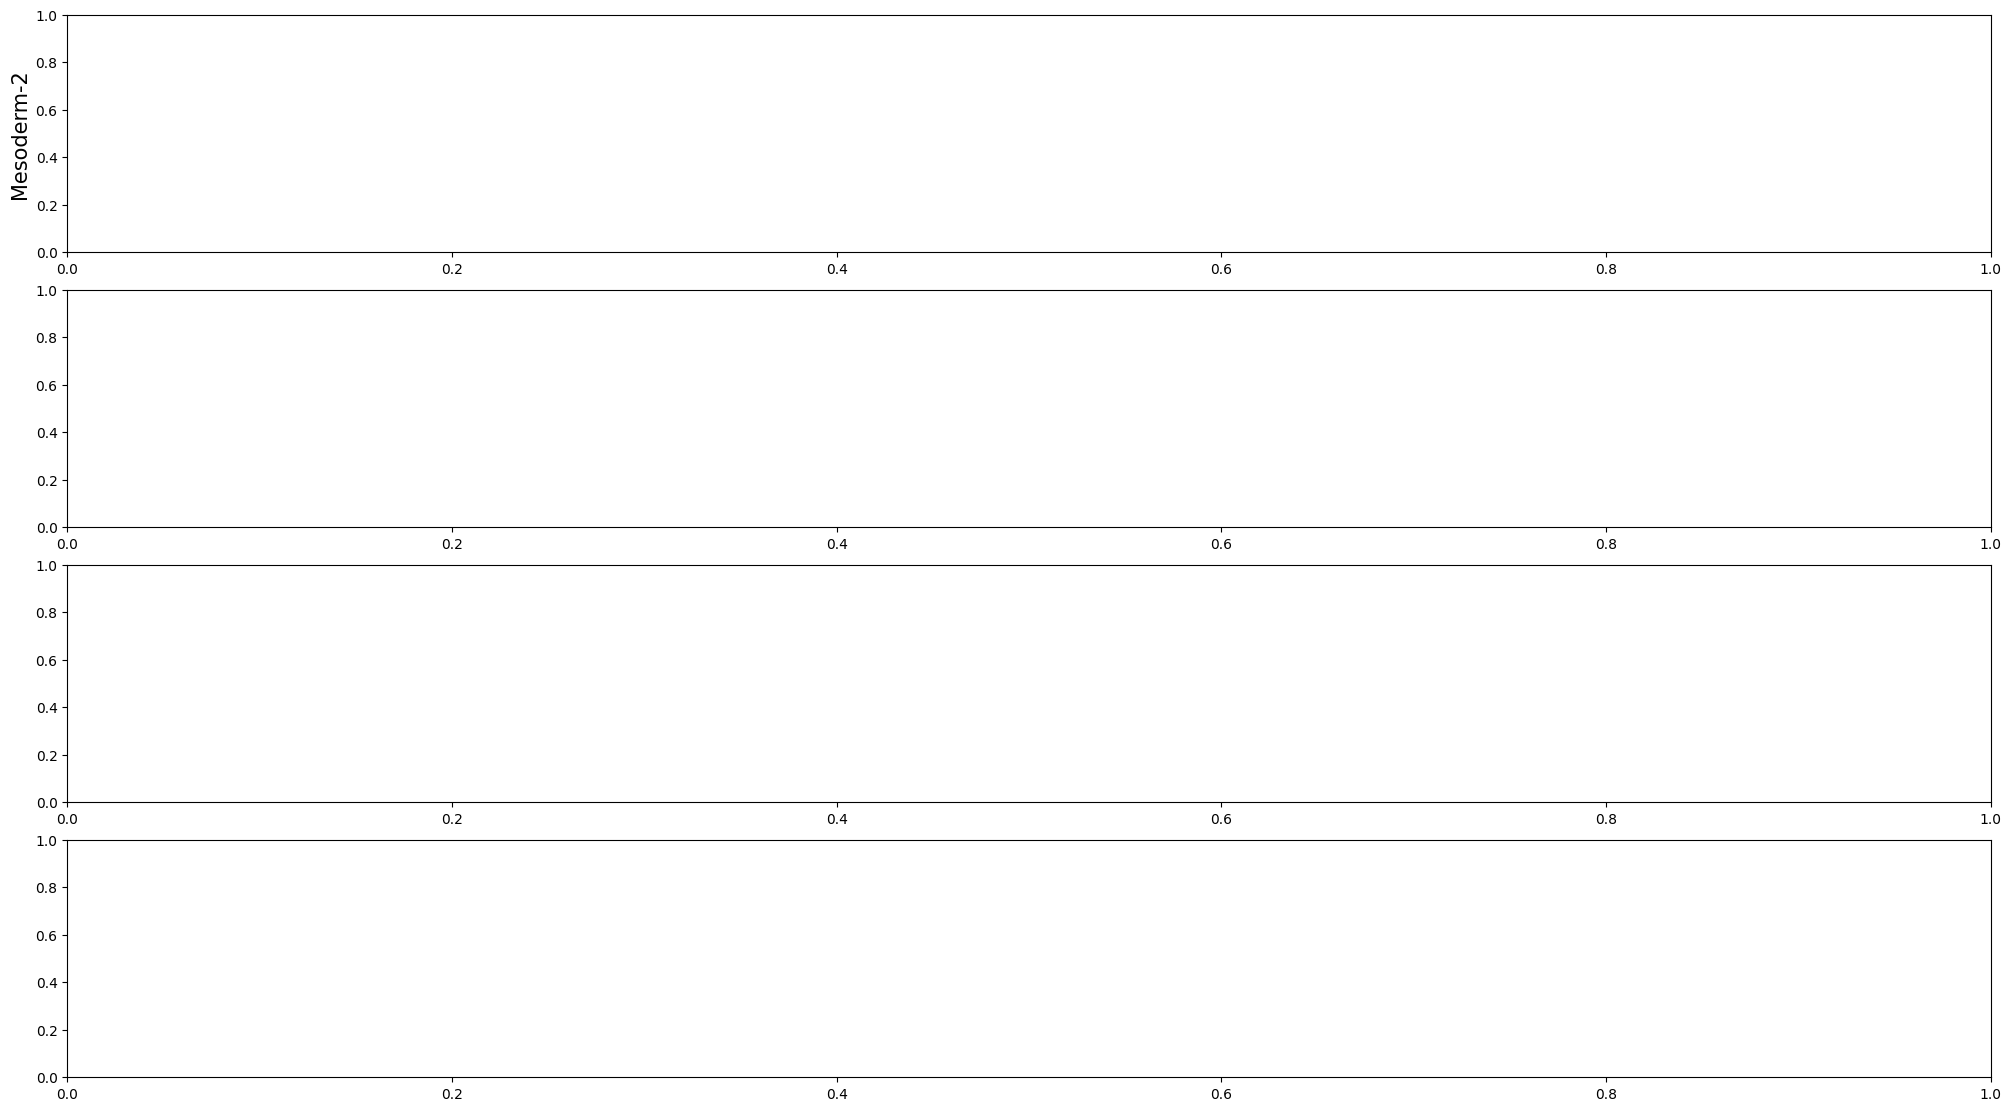

In [53]:
cf.histograms_distances( distances.copy(), reference_clusters.copy(), clusters.copy() )

In [ ]:
#cf.alignment_table_interset_oneway( cut_off, distances.copy(), clusters.copy(), reference_clusters.copy())#

In [57]:
from collections import defaultdict
import plotly.graph_objects as go
import numpy as np # Assuming numpy is available for array operations

def make_sankey_ordered2(labels, sources, targets, values, title):
    """
    Makes an ordered Sankey diagram where each connection is colored by its source node,
    and the source nodes themselves share that same color.
    """
    
    # Create a dictionary to count links for each node
    link_count = defaultdict(lambda: {'source': 0, 'target': 0})
    for src, tgt in zip(sources, targets):
        link_count[src]['source'] += 1
        link_count[tgt]['target'] += 1
    
    # Define sorting criteria
    def sorting_criteria(link):
        src, tgt = link[0], link[1]
        src_count, tgt_count = link_count[src], link_count[tgt]
        is_SL = src_count['source'] == 1 and tgt_count['target'] == 1
        is_S_two_T_not_target = src_count['source'] == 2 and tgt_count['target'] == 0
        is_S_two_T_can_be_target = src_count['source'] == 2
        is_S_more_than_two_T_not_target = src_count['source'] > 2 and tgt_count['target'] == 0
        return (is_SL, is_S_two_T_not_target, is_S_two_T_can_be_target, is_S_more_than_two_T_not_target)

    # Sort links based on criteria
    sorted_links = sorted(zip(sources, targets, values), key=sorting_criteria, reverse=True)
    
    # Unzip the sorted links
    sorted_sources, sorted_targets, sorted_values = zip(*sorted_links)

    # --- Color connections by source node and set source node colors ---
    # Define a color palette. You can expand this list for more distinct colors.
    # These are semi-transparent for better visualization of overlaps.
    color_palette = [
        'rgba(31, 119, 180, 0.5)',  # Blue (increased opacity for nodes)
        'rgba(255, 127, 14, 0.5)',  # Orange
        'rgba(44, 160, 44, 0.5)',   # Green
        'rgba(214, 39, 40, 0.5)',   # Red
        'rgba(148, 103, 189, 0.5)', # Purple
        'rgba(140, 86, 75, 0.5)',   # Brown
        'rgba(227, 119, 194, 0.5)', # Pink
        'rgba(127, 127, 127, 0.5)', # Gray
        'rgba(188, 189, 34, 0.5)',  # Olive
        'rgba(23, 190, 207, 0.5)'   # Cyan
    ]

    # Create a mapping from unique source node indices to colors
    unique_source_indices = np.unique(sources)
    source_index_to_color = {
        idx: color_palette[i % len(color_palette)]
        for i, idx in enumerate(unique_source_indices)
    }

    # Generate the list of colors for each link based on its source node
    # Links will have their corresponding source color
    link_colors = [source_index_to_color[src] for src in sorted_sources]

    # Generate the list of colors for each node
    # The 'labels' list contains all node labels (source and target).
    # We assume 'sources' indices refer to the first half of 'labels'.
    # For source nodes, use their assigned color. For target nodes, use a neutral color.
    node_colors = []
    default_target_node_color = 'rgba(200, 200, 200, 0.8)' # Light gray for target nodes
    
    # Iterate through all possible node indices (0 to len(labels) - 1)
    for i in range(len(labels)):
        if i in source_index_to_color:
            # This node is a source node that actually has outgoing links
            node_colors.append(source_index_to_color[i])
        else:
            # This node is either a target node or a source node with no outgoing links
            node_colors.append(default_target_node_color)

    fig = go.Figure(go.Sankey(
        node={
            "label": labels,
            'pad': 10,
            'thickness': 15,
            "color": node_colors # Apply the generated node colors here
        },
        link={
            "source": sorted_sources,
            "target": sorted_targets,
            "value": sorted_values,
            "color": link_colors # Links remain colored by their source
        }
    ))

    fig.update_layout(title_text=title, font_size=25, height=900)
    fig.write_html("S2toS3-FL_sankey_diagram_interset.html")

    # fig.show() # Keep commented out as per original

In [58]:
def alignment_diagram_interset_oneway(cut_off, 
                                      distances: np.array, 
                                      clusters: np.array, 
                                      reference_clusters: np.array, 
                                      remove_this: np.array, 
                                      normalize,
                                      cluster_sizes: list,
                                      reference_cluster_sizes: list):
    """
    Function makes qs_df - a DataFrame, which contains mean distances and signifcances of distances between clusters 
    and reference clusters. It filters out clusters with significance <= cut_off, and visualizes the significant alignments using a 
    Sankey diagram (where thinkness of link is inversely proportional to mean distance bewteen source and target), with function 
    make_sankey_ordered (sankey is saved as .html)
    
    Args:
        cut_off (float): The cut-off value for the 'q_ij' metric.
        distances (np.array): A 3D array of distances between clusters and reference clusters.
        clusters (np.array):
        reference_clusters (np.array): 
        remove_this (np.array): Clusters that contain fewer than 50 cells, and were removed.
        normalize (bool): Flag indicating whether clusters were non-zero median normalized together.    
    """
    
    means = np.mean( distances, axis=0 )  
    
    targets = []
    sources = []
    values = []
    
    
    
    qs_df = cf.qs_directed_interset(clusters.copy(), 
                                reference_clusters.copy(), 
                                np.mean( distances, axis=0 ), 
                                np.std( distances, axis=0 ))

    for c, cluster in enumerate(clusters):        
        
        matching_rows = qs_df[qs_df['oc'] == cluster]        
        filtered_rows = matching_rows[matching_rows['q_ij'] <= cut_off]
        source_cluster_size = cluster_sizes[c]
        
        for _, row in filtered_rows.iterrows():
            aligned_cluster_index = np.where(reference_clusters==row['c_j'])[0][0]
            targets.append(len(clusters) + aligned_cluster_index)
            sources.append(c)
            values.append(source_cluster_size)
   
    ref_cl_clean = []
    for rc in reference_clusters: 
        ref_cl_clean.append(rc[:-3]) 

    labels = [*clusters , *reference_clusters]
    
    print('remove_this', remove_this)

    if remove_this.size==0:  
        title = "CAT. "
    else: 
        title = f"CAT. Removed clusters with fewer than 50 cells: {remove_this}"            
    
    if normalize:
        title += " Non-zero median normalized"
    make_sankey_ordered2(labels, sources, targets, values, title)

In [59]:
cut_off = 10

alignment_diagram_interset_oneway(cut_off, distances.copy(), clusters.copy(), reference_clusters.copy(), 
                                  np.concatenate((removed_clusts, removed_ref_clust)), 
                                  normalize,
                                 cluster_sizes=cluster_sizes,
                                 reference_cluster_sizes=cluster_sizes_ref)

remove_this ['IM-2' 'Mesoderm-1' 'IM-1' 'pPSM' 'AdvMeso-1_re' 'AdvMeso-2_re' 'pNPC_re'
 'Early_Nephron_re' 'IM-3_re' 'NPC-1_re' 'Early_Stroma_re']


In [15]:
from pycirclize import Circos
import pandas as pd

# Create matrix dataframe (3 x 6)
row_names = ["F1", "F2", "F3"]
col_names = ["T1", "T2", "T3", "T4", "T5", "T6"]
matrix_data = [
    [10, 16, 7, 7, 10, 8],
    [4, 9, 10, 12, 12, 7],
    [17, 13, 7, 4, 20, 4],
]
matrix_df = pd.DataFrame(matrix_data, index=row_names, columns=col_names)

# Initialize Circos instance for chord diagram plot
circos = Circos.chord_diagram(
    matrix_df,
    space=5,
    cmap="tab10",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1),
)

ModuleNotFoundError: No module named 'pycirclize'